# Privacy-Centric Federated IDS Experiments

This notebook is structured around the **correct research idea**: the proposed method is evaluated primarily as a **privacy-preserving, robust, distributed intrusion-detection framework** with **competitive utility**, not as a raw-accuracy winner against centralized tree baselines.

Accordingly, the notebook emphasizes:
- privacy–utility trade-off
- ablation of privacy/security components
- robustness under adversarial clients
- competitive but secondary comparison against centralized baselines


In [ ]:

# Optional installs for a fresh notebook environment
import sys, subprocess, importlib, warnings

def ensure_package(pkg_name, import_name=None):
    import_name = import_name or pkg_name
    try:
        importlib.import_module(import_name)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg_name])

for pkg_name, import_name in [
    ("xgboost", "xgboost"),
    ("lightgbm", "lightgbm"),
    ("kagglehub", "kagglehub"),
    ("scipy", "scipy"),
]:
    ensure_package(pkg_name, import_name)

warnings.filterwarnings("ignore")


In [ ]:
import os, gc, re, json, math, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA

from scipy.stats import wilcoxon, friedmanchisquare, rankdata

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cpu


## Dataset download and loading

In [ ]:

DATA_ROOT = Path("./external_ids_datasets")
DATA_ROOT.mkdir(exist_ok=True, parents=True)

KAGGLE_DATASETS = {
    "NSL-KDD": ["hassan06/nslkdd"],
    "UNSW-NB15": ["dhoogla/unswnb15", "mrwellsdavid/unsw-nb15", "ucimachinelearning/unsw-nb15-dataset"],
    "CIC-DDoS2019": ["dhoogla/cicddos2019"],
}

READABLE_EXTS = {".csv", ".txt", ".data", ".arff", ".parquet", ".feather"}

NSL_COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

def try_kagglehub_download(dataset_handle: str) -> Path:
    import kagglehub
    return Path(kagglehub.dataset_download(dataset_handle))

def find_candidate_files(root: Path):
    return sorted([p for p in root.rglob("*") if p.suffix.lower() in READABLE_EXTS])

def read_any_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if path.name.lower().startswith(("kddtrain", "kddtest")) and suffix == ".txt":
        df = pd.read_csv(path, header=None)
        if df.shape[1] == len(NSL_COLUMNS):
            df.columns = NSL_COLUMNS
        return df

    if suffix == ".csv":
        return pd.read_csv(path, low_memory=False)
    if suffix in {".txt", ".data"}:
        return pd.read_csv(path, header=None, low_memory=False)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix == ".feather":
        return pd.read_feather(path)
    if suffix == ".arff":
        from scipy.io import arff
        data, meta = arff.loadarff(path)
        return pd.DataFrame(data)

    raise ValueError(f"Unsupported file type: {path}")

def normalize_binary_target(series: pd.Series) -> pd.Series:
    s = series.copy()

    def convert(v):
        if isinstance(v, bytes):
            v = v.decode("utf-8", errors="ignore")
        if isinstance(v, str):
            t = v.strip().lower()
            if t in {"normal", "normal.", "benign", "0"}:
                return 0
            return 1
        try:
            return int(v != 0)
        except Exception:
            return 1

    return s.map(convert).astype(int)

def cleanup_object_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        if out[col].dtype == object:
            out[col] = out[col].map(lambda v: v.decode("utf-8", errors="ignore") if isinstance(v, bytes) else v)
    return out


def drop_dataset_specific_leakage_columns(X: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    dataset_specific = {
        "UNSW-NB15": {"attack_cat", "id"},
        "CIC-DDoS2019": {"label", "flow id"},
    }
    generic_identifier_cols = {"id", "flow id", "flow_id", "timestamp"}
    lower_map = {c.lower(): c for c in X.columns}

    drop_cols = set()
    for token in dataset_specific.get(dataset_name, set()) | generic_identifier_cols:
        if token in lower_map:
            drop_cols.add(lower_map[token])

    if drop_cols:
        X = X.drop(columns=sorted(drop_cols), errors="ignore")
    return X

def infer_X_y(df: pd.DataFrame, dataset_name: str):
    df = cleanup_object_columns(df)

    if dataset_name == "NSL-KDD":
        if df.shape[1] == len(NSL_COLUMNS):
            df.columns = NSL_COLUMNS
        target_col = "label"
        X = df.drop(columns=[c for c in ["label", "difficulty"] if c in df.columns]).copy()
        X = drop_dataset_specific_leakage_columns(X, dataset_name)
        y = normalize_binary_target(df[target_col])
        return X, y

    lower_cols = {c.lower(): c for c in df.columns}
    target_candidates = [
        "label", "attack_cat", "class", "binary_label", "target", "outcome"
    ]
    target_col = None
    for c in target_candidates:
        if c in lower_cols:
            target_col = lower_cols[c]
            break

    if target_col is None:
        target_col = df.columns[-1]

    companion_target_like = {"label", "attack_cat", "class", "binary_label", "target", "outcome"}
    drop_cols = []
    for token in companion_target_like:
        if token in lower_cols and lower_cols[token] != target_col:
            drop_cols.append(lower_cols[token])

    X = df.drop(columns=[target_col, *drop_cols], errors="ignore").copy()
    X = drop_dataset_specific_leakage_columns(X, dataset_name)
    y = normalize_binary_target(df[target_col])
    return X, y

    lower_cols = {c.lower(): c for c in df.columns}
    target_candidates = [
        "label", "attack_cat", "class", "binary_label", "target", "outcome"
    ]
    target_col = None
    for c in target_candidates:
        if c in lower_cols:
            target_col = lower_cols[c]
            break

    if target_col is None:
        target_col = df.columns[-1]

    X = df.drop(columns=[target_col]).copy()
    y = normalize_binary_target(df[target_col])
    return X, y

def load_dataset_external(dataset_name: str, max_rows: int | None = 50000):
    dataset_dir = DATA_ROOT / dataset_name
    dataset_dir.mkdir(exist_ok=True, parents=True)

    if not any(dataset_dir.rglob("*")):
        handles = KAGGLE_DATASETS[dataset_name]
        last_error = None
        for handle in handles:
            try:
                print(f"[download] Trying KaggleHub for {dataset_name} -> {handle}")
                downloaded = try_kagglehub_download(handle)
                if downloaded.exists():
                    return load_dataset_from_root(downloaded, dataset_name, max_rows=max_rows)
            except Exception as e:
                last_error = e
                print(f"[warn] download failed for {handle}: {e}")
        raise RuntimeError(f"Could not download {dataset_name}: {last_error}")

    return load_dataset_from_root(dataset_dir, dataset_name, max_rows=max_rows)

def load_dataset_from_root(root: Path, dataset_name: str, max_rows: int | None = 50000):
    files = find_candidate_files(root)
    if not files:
        raise FileNotFoundError(f"No readable files found under {root}")

    print(f"[info] Found {len(files)} candidate files for {dataset_name}")
    dataframes = []
    for path in files:
        try:
            df = read_any_table(path)
            if len(df) == 0:
                continue
            X, y = infer_X_y(df, dataset_name)
            X = cleanup_object_columns(X)
            dataframes.append(pd.concat([X, y.rename("__target__")], axis=1))
            print("   ->", path.name, X.shape)
        except Exception as e:
            print(f"[warn] failed reading {path.name}: {e}")

    if not dataframes:
        raise RuntimeError(f"No usable tables were loaded for {dataset_name}")

    df = pd.concat(dataframes, axis=0, ignore_index=True)
    df = df.dropna(axis=1, how="all").dropna(axis=0, how="all").reset_index(drop=True)

    if max_rows is not None and len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=SEED).reset_index(drop=True)

    X = df.drop(columns=["__target__"]).copy()
    y = df["__target__"].astype(int).copy()
    print(f"{dataset_name}: X={X.shape}, positive_rate={y.mean():.4f}")
    return X, y


## Leakage-safe preprocessing and splitting

In [ ]:
def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def deduplicate_before_split(X: pd.DataFrame, y: pd.Series):
    df = X.copy()
    df["__target__"] = y.values
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    after = len(df)
    X_out = df.drop(columns=["__target__"])
    y_out = df["__target__"].astype(int)
    return X_out, y_out, before - after

def build_preprocessor(X_train: pd.DataFrame):
    X_train = cleanup_object_columns(X_train)
    cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in X_train.columns if c not in cat_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder())
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ], remainder="drop")
    return preprocessor, num_cols, cat_cols

def split_raw_dataset(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.20,
    val_size: float = 0.10,
    deduplicate: bool = True,
):
    X = cleanup_object_columns(X.copy())
    y = pd.Series(y).copy().astype(int)

    duplicates_removed = 0
    if deduplicate:
        X, y, duplicates_removed = deduplicate_before_split(X, y)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=SEED
    )

    val_ratio = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_ratio, stratify=y_train_full, random_state=SEED
    )

    info = {
        "duplicates_removed": int(duplicates_removed),
        "n_train": int(len(y_train)),
        "n_val": int(len(y_val)),
        "n_test": int(len(y_test)),
    }
    return X_train, X_val, X_test, y_train, y_val, y_test, info

def fit_feature_pipeline(
    X_train_raw: pd.DataFrame,
    y_train,
    X_val_raw: pd.DataFrame,
    X_test_raw: pd.DataFrame,
    variance_threshold: float = 0.0,
    feature_mode: str = "selectkbest",
    k_best: int = 128,
    pca_components = None,
):
    preprocessor, num_cols, cat_cols = build_preprocessor(X_train_raw)

    X_train_t = preprocessor.fit_transform(X_train_raw)
    X_val_t = preprocessor.transform(X_val_raw)
    X_test_t = preprocessor.transform(X_test_raw)

    X_train_t = np.asarray(X_train_t, dtype=np.float32)
    X_val_t = np.asarray(X_val_t, dtype=np.float32)
    X_test_t = np.asarray(X_test_t, dtype=np.float32)

    selector = None
    selector_name = "none"
    n_before_selection = int(X_train_t.shape[1])

    if variance_threshold > 0:
        vt = VarianceThreshold(threshold=variance_threshold)
        X_train_t = vt.fit_transform(X_train_t)
        X_val_t = vt.transform(X_val_t)
        X_test_t = vt.transform(X_test_t)
        selector = vt
        selector_name = f"variance_threshold_{variance_threshold}"

    if feature_mode == "selectkbest":
        k = min(k_best, X_train_t.shape[1])
        skb = SelectKBest(score_func=mutual_info_classif, k=k)
        X_train_t = skb.fit_transform(X_train_t, y_train)
        X_val_t = skb.transform(X_val_t)
        X_test_t = skb.transform(X_test_t)
        selector = skb
        selector_name = f"selectkbest_mutual_info_{k}"
    elif feature_mode == "pca":
        if pca_components is None:
            pca_components = min(64, X_train_t.shape[1])
        pca = PCA(n_components=pca_components, random_state=SEED)
        X_train_t = pca.fit_transform(X_train_t)
        X_val_t = pca.transform(X_val_t)
        X_test_t = pca.transform(X_test_t)
        selector = pca
        selector_name = f"pca_{pca_components}"

    info = {
        "n_features_before_selection": int(n_before_selection),
        "n_features_after_encoding": int(X_train_t.shape[1]),
        "n_numeric": int(len(num_cols)),
        "n_categorical": int(len(cat_cols)),
        "selector_used": selector is not None,
        "selector_name": selector_name,
        "feature_mode": feature_mode,
        "k_best": int(min(k_best, n_before_selection)),
        "pca_components": pca_components if pca_components is not None else np.nan,
    }

    return (
        np.asarray(X_train_t, dtype=np.float32),
        np.asarray(X_val_t, dtype=np.float32),
        np.asarray(X_test_t, dtype=np.float32),
        preprocessor,
        selector,
        info,
    )

def preprocess_dataset(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.20,
    val_size: float = 0.10,
    deduplicate: bool = True,
    variance_threshold: float = 0.0,
    feature_mode: str = "selectkbest",
    k_best: int = 128,
    pca_components = None,
):
    X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test, split_info = split_raw_dataset(
        X, y, test_size=test_size, val_size=val_size, deduplicate=deduplicate
    )

    X_train_t, X_val_t, X_test_t, preprocessor, selector, feat_info = fit_feature_pipeline(
        X_train_raw, y_train, X_val_raw, X_test_raw,
        variance_threshold=variance_threshold,
        feature_mode=feature_mode,
        k_best=k_best,
        pca_components=pca_components,
    )

    y_train = np.asarray(y_train, dtype=np.int64)
    y_val = np.asarray(y_val, dtype=np.int64)
    y_test = np.asarray(y_test, dtype=np.int64)

    info = {**split_info, **feat_info}
    return (
        X_train_t, X_val_t, X_test_t, y_train, y_val, y_test,
        preprocessor, selector, info,
        X_train_raw, X_val_raw, X_test_raw
    )

## Metrics and strong centralized baselines

In [ ]:
def build_metrics(y_true, probs, threshold=0.5):
    probs = np.asarray(probs, dtype=float)
    probs = np.clip(np.nan_to_num(probs, nan=0.5, posinf=1.0, neginf=0.0), 0.0, 1.0)
    preds = (probs >= threshold).astype(int)

    return {
        "Accuracy": float(accuracy_score(y_true, preds)),
        "Precision": float(precision_score(y_true, preds, zero_division=0)),
        "Recall": float(recall_score(y_true, preds, zero_division=0)),
        "F1": float(f1_score(y_true, preds, zero_division=0)),
        "ROC-AUC": float(roc_auc_score(y_true, probs)) if len(np.unique(y_true)) > 1 else np.nan,
        "PR-AP": float(average_precision_score(y_true, probs)) if len(np.unique(y_true)) > 1 else np.nan,
        "Threshold": float(threshold),
        "ConfusionMatrix": confusion_matrix(y_true, preds),
        "Pred": preds,
        "Prob": probs,
    }

def find_best_threshold(y_true, probs):
    thresholds = np.linspace(0.10, 0.90, 81)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        f1 = f1_score(y_true, (probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_t, best_f1 = float(t), float(f1)
    return best_t, best_f1

def compute_class_weight_ratio(y):
    y = np.asarray(y).astype(int)
    counts = np.bincount(y, minlength=2)
    neg, pos = counts[0], counts[1]
    if pos == 0:
        return 1.0
    return float(neg / max(pos, 1))

def make_xgb(scale_pos_weight):
    return XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.5,
        min_child_weight=2,
        gamma=0.0,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        tree_method="hist",
        n_jobs=2,
    )

def make_lgbm(scale_pos_weight):
    return LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.5,
        min_child_samples=20,
        scale_pos_weight=scale_pos_weight,
        objective="binary",
        random_state=SEED,
        verbose=-1,
    )

def evaluate_sklearn_model(model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)
    val_probs = model.predict_proba(X_val)[:, 1]
    threshold, _ = find_best_threshold(y_val, val_probs)
    test_probs = model.predict_proba(X_test)[:, 1]
    return build_metrics(y_test, test_probs, threshold=threshold)

def cross_validate_baseline_raw(
    model_builder, X_raw, y_raw, n_splits=5,
    variance_threshold=0.0, feature_mode="selectkbest", k_best=128, pca_components=None
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rows = []
    X_raw = cleanup_object_columns(X_raw.copy())
    y_raw = pd.Series(y_raw).astype(int).reset_index(drop=True)
    X_raw = X_raw.reset_index(drop=True)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_raw, y_raw), start=1):
        X_tr_raw, X_va_raw = X_raw.iloc[tr_idx].copy(), X_raw.iloc[va_idx].copy()
        y_tr, y_va = y_raw.iloc[tr_idx].to_numpy(dtype=np.int64), y_raw.iloc[va_idx].to_numpy(dtype=np.int64)

        X_tr, X_va, _, _, _, feat_info = fit_feature_pipeline(
            X_tr_raw, y_tr, X_va_raw, X_va_raw,
            variance_threshold=variance_threshold,
            feature_mode=feature_mode,
            k_best=k_best,
            pca_components=pca_components,
        )

        spw = compute_class_weight_ratio(y_tr)
        model = model_builder(spw)
        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_va)[:, 1]
        t, _ = find_best_threshold(y_va, probs)
        metrics = build_metrics(y_va, probs, threshold=t)
        rows.append({
            "fold": fold,
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "F1": metrics["F1"],
            "ROC-AUC": metrics["ROC-AUC"],
            "PR-AP": metrics["PR-AP"],
            "n_features_after_encoding": feat_info["n_features_after_encoding"],
        })
    df = pd.DataFrame(rows)
    summary = {f"{col}_mean": float(df[col].mean()) for col in df.columns if col != "fold"}
    summary.update({f"{col}_std": float(df[col].std(ddof=1)) for col in df.columns if col != "fold"})
    return df, summary

def safe_wilcoxon(x, y, alternative="two-sided"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2 or len(y) < 2 or len(x) != len(y):
        return np.nan, np.nan
    if np.allclose(x, y):
        return 0.0, 1.0
    stat, p = wilcoxon(x, y, alternative=alternative, zero_method="wilcox")
    return float(stat), float(p)

def friedman_rank_test(score_dict):
    keys = list(score_dict.keys())
    arrays = [np.asarray(score_dict[k], dtype=float) for k in keys]
    min_len = min(len(a) for a in arrays)
    arrays = [a[:min_len] for a in arrays]
    if min_len < 2:
        return {"statistic": np.nan, "p_value": np.nan, "avg_ranks": {k: np.nan for k in keys}}
    stat, p = friedmanchisquare(*arrays)
    rank_matrix = np.vstack([rankdata([-v for v in vals], method="average") for vals in zip(*arrays)])
    avg_ranks = rank_matrix.mean(axis=0)
    return {
        "statistic": float(stat),
        "p_value": float(p),
        "avg_ranks": {k: float(r) for k, r in zip(keys, avg_ranks)}
    }

## Centralized MLP and Federated MLP

In [ ]:

class TabularMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.net(x)

def get_model_params(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def set_model_params(model, params):
    model.load_state_dict(params)

def flatten_params(params):
    return torch.cat([v.reshape(-1).float().cpu() for v in params.values()])

def params_diff(local_params, global_params):
    return {k: local_params[k] - global_params[k] for k in local_params.keys()}

def clip_update(update, max_norm=1.0):
    flat = flatten_params(update)
    total_norm = float(torch.norm(flat).item())
    scale = min(1.0, max_norm / (total_norm + 1e-12))
    clipped = {k: v * scale for k, v in update.items()}
    return clipped, total_norm, scale

def add_gaussian_noise(update, sigma):
    noisy = {}
    for k, v in update.items():
        noise = torch.normal(mean=0.0, std=sigma, size=v.shape, device=v.device, dtype=v.dtype)
        noisy[k] = v + noise
    return noisy

def weighted_average_updates(updates, weights):
    out = {}
    for k in updates[0].keys():
        out[k] = sum(w * u[k] for w, u in zip(weights, updates))
    return out

def compute_class_weights(y):
    counts = np.bincount(np.asarray(y, dtype=np.int64), minlength=2).astype(np.float32)
    counts[counts == 0] = 1.0
    weights = counts.sum() / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)

def predict_proba_torch(model, X, batch_size=1024):
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32, device=DEVICE)
            logits = model(xb)
            pb = torch.softmax(logits, dim=1)[:, 1]
            probs.append(pb.detach().cpu().numpy())
    return np.clip(np.concatenate(probs), 0.0, 1.0)

def train_centralized_mlp(X_train, y_train, X_val, y_val, X_test, y_test,
                          epochs=20, lr=1e-3, batch_size=256, patience=4):
    model = TabularMLP(X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=compute_class_weights(y_train))
    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
    effective_bs = max(2, min(batch_size, len(train_ds)))
    loader = DataLoader(
        train_ds,
        batch_size=effective_bs,
        shuffle=True,
        drop_last=(len(train_ds) > effective_bs and len(train_ds) % effective_bs == 1),
    )

    best_state = None
    best_threshold = 0.5
    best_val_f1 = -1.0
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        val_probs = predict_proba_torch(model, X_val)
        threshold, val_f1 = find_best_threshold(y_val, val_probs)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_threshold = threshold
            best_state = get_model_params(model)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping centralized MLP at epoch {epoch+1}, best val F1={best_val_f1:.4f}")
                break

    if best_state is not None:
        set_model_params(model, best_state)

    test_probs = predict_proba_torch(model, X_test)
    metrics = build_metrics(y_test, test_probs, threshold=best_threshold)
    return model, metrics


def dirichlet_non_iid_partition(y, num_clients=10, alpha=0.3, min_size=50, max_tries=25):
    y = np.asarray(y, dtype=np.int64)
    n_classes = len(np.unique(y))
    all_indices = np.arange(len(y))

    for _ in range(max_tries):
        client_map = {cid: [] for cid in range(num_clients)}
        for cls in range(n_classes):
            cls_idx = all_indices[y == cls]
            np.random.shuffle(cls_idx)
            proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
            cut_points = (np.cumsum(proportions) * len(cls_idx)).astype(int)[:-1]
            splits = np.split(cls_idx, cut_points)
            for cid, split in enumerate(splits):
                client_map[cid].extend(split.tolist())

        sizes = [len(v) for v in client_map.values()]
        if min(sizes) >= min_size:
            return {cid: np.array(v, dtype=int) for cid, v in client_map.items()}

    # Fallback to shard-based non-IID partition if Dirichlet is too imbalanced
    return non_iid_shard_partition(y, num_clients=num_clients, shards_per_client=2)

def non_iid_shard_partition(y, num_clients=10, shards_per_client=2):
    y = np.asarray(y)
    idxs = np.arange(len(y))
    idxs_labels = np.vstack((idxs, y))
    idxs_labels = idxs_labels[:, idxs_labels[1].argsort()]
    idxs_sorted = idxs_labels[0]
    num_shards = num_clients * shards_per_client
    shard_size = max(1, len(y) // num_shards)
    shards = [idxs_sorted[i*shard_size:(i+1)*shard_size] for i in range(num_shards)]
    leftovers = idxs_sorted[num_shards*shard_size:]
    random.shuffle(shards)
    client_map = {}
    for cid in range(num_clients):
        chosen = shards[cid*shards_per_client:(cid+1)*shards_per_client]
        client_map[cid] = np.concatenate(chosen) if chosen else np.array([], dtype=int)
    for i, idx in enumerate(leftovers):
        client_map[i % num_clients] = np.append(client_map[i % num_clients], idx)
    return client_map

def non_iid_partition(y, num_clients=10, shards_per_client=2):
    return dirichlet_non_iid_partition(y, num_clients=num_clients, alpha=0.3, min_size=max(20, len(y)//(num_clients*8)))
def iid_partition(y, num_clients=10):
    idx = np.arange(len(y))
    np.random.shuffle(idx)
    splits = np.array_split(idx, num_clients)
    return {i: splits[i] for i in range(num_clients)}

def train_one_client(global_params, X_train, y_train, client_idx, input_dim,
                     local_epochs=2, lr=1e-3, batch_size=256,
                     use_privacy=True, base_sigma=0.02,
                     attack_mode=None, max_grad_norm=1.0):
    model = TabularMLP(input_dim).to(DEVICE)
    set_model_params(model, global_params)

    Xc = torch.tensor(X_train[client_idx], dtype=torch.float32)
    yc = torch.tensor(y_train[client_idx], dtype=torch.long)

    if attack_mode == "label_flip":
        yc = 1 - yc

    if len(client_idx) < 2:
        meta = {
            "n_samples": int(len(client_idx)),
            "loss": 0.0,
            "sigma": 0.0,
            "update_norm": 0.0,
            "clip_scale": 1.0,
            "reliability": 1e-6,
        }
        zero_update = {k: torch.zeros_like(v) for k, v in global_params.items()}
        return zero_update, meta

    client_ds = TensorDataset(Xc, yc)
    effective_bs = max(2, min(batch_size, len(client_ds)))
    loader = DataLoader(
        client_ds,
        batch_size=effective_bs,
        shuffle=True,
        drop_last=(len(client_ds) > effective_bs and len(client_ds) % effective_bs == 1),
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=compute_class_weights(yc.cpu().numpy()))

    epoch_losses = []
    for _ in range(local_epochs):
        model.train()
        batch_losses = []
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            batch_losses.append(loss.item())
        epoch_losses.append(float(np.mean(batch_losses)) if batch_losses else 0.0)

    local_params = get_model_params(model)
    update = params_diff(local_params, global_params)
    update, update_norm, clip_scale = clip_update(update, max_norm=max_grad_norm)

    if attack_mode == "poison_update":
        update = {k: v * 5.0 for k, v in update.items()}

    sigma_used = 0.0
    if use_privacy:
        sigma_used = float(base_sigma)
        update = add_gaussian_noise(update, sigma=sigma_used)

    meta = {
        "n_samples": int(len(client_idx)),
        "loss": float(np.mean(epoch_losses) if epoch_losses else 0.0),
        "sigma": float(sigma_used),
        "update_norm": float(update_norm),
        "clip_scale": float(clip_scale),
        "reliability": float(1.0 / (1.0 + np.mean(epoch_losses) + 0.05 * update_norm)),
    }
    return update, meta

def filter_and_aggregate(updates, metas, global_params, use_byzantine=True, use_context=True, z_thresh=2.5):
    vectors = [flatten_params(u).numpy().astype(np.float32) for u in updates]
    norms = np.array([np.linalg.norm(v) for v in vectors])
    keep_mask = np.ones(len(updates), dtype=bool)

    if use_byzantine and len(norms) >= 3 and norms.std() > 1e-12:
        z = (norms - norms.mean()) / (norms.std() + 1e-8)
        keep_mask = np.abs(z) < z_thresh

    filtered_updates = [u for u, keep in zip(updates, keep_mask) if keep]
    filtered_metas = [m for m, keep in zip(metas, keep_mask) if keep]

    if not filtered_updates:
        filtered_updates, filtered_metas = updates, metas

    if use_context:
        weights = np.array([
            max(1e-6, m["n_samples"] * m["reliability"])
            for m in filtered_metas
        ], dtype=float)
    else:
        weights = np.array([m["n_samples"] for m in filtered_metas], dtype=float)

    weights = weights / weights.sum()
    avg_update = weighted_average_updates(filtered_updates, weights)

    new_global = {k: global_params[k] + avg_update[k] for k in global_params.keys()}
    info = {
        "n_received": len(updates),
        "n_kept": len(filtered_updates),
        "weights": weights.tolist(),
    }
    return new_global, info

def federated_experiment(
    X_train, y_train, X_val, y_val, X_test, y_test,
    num_clients=10, fl_rounds=20, local_epochs=2, lr=1e-3, batch_size=256,
    base_sigma=0.02, use_privacy=True, use_context=True, use_byzantine=True,
    attack_clients=None, attack_mode=None, partitioner=non_iid_partition, patience=5
):
    input_dim = X_train.shape[1]
    global_model = TabularMLP(input_dim).to(DEVICE)
    global_params = get_model_params(global_model)
    client_indices = partitioner(y_train, num_clients=num_clients)

    history = []
    best_params = None
    best_threshold = 0.5
    best_val_f1 = -1.0
    rounds_without_improvement = 0

    for rnd in range(fl_rounds):
        updates, metas = [], []
        round_start = time.time()

        for cid in range(num_clients):
            cid_attack = attack_mode if attack_clients is not None and cid in attack_clients else None
            update, meta = train_one_client(
                global_params, X_train, y_train, client_indices[cid], input_dim,
                local_epochs=local_epochs, lr=lr, batch_size=batch_size,
                use_privacy=use_privacy, base_sigma=base_sigma, attack_mode=cid_attack,
            )
            updates.append(update)
            metas.append(meta)

        global_params, agg_info = filter_and_aggregate(
            updates, metas, global_params,
            use_byzantine=use_byzantine, use_context=use_context
        )
        set_model_params(global_model, global_params)

        val_probs = predict_proba_torch(global_model, X_val)
        threshold, val_f1 = find_best_threshold(y_val, val_probs)

        test_probs = predict_proba_torch(global_model, X_test)
        metrics = build_metrics(y_test, test_probs, threshold=threshold)

        history.append({
            "round": rnd + 1,
            "val_f1": float(val_f1),
            "test_f1": float(metrics["F1"]),
            "test_acc": float(metrics["Accuracy"]),
            "test_roc_auc": float(metrics["ROC-AUC"]),
            "avg_sigma": float(np.mean([m["sigma"] for m in metas])),
            "avg_update_norm": float(np.mean([m["update_norm"] for m in metas])),
            "avg_reliability": float(np.mean([m["reliability"] for m in metas])),
            "n_kept": int(agg_info["n_kept"]),
            "time_sec": float(time.time() - round_start),
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_threshold = threshold
            best_params = get_model_params(global_model)
            rounds_without_improvement = 0
        else:
            rounds_without_improvement += 1

        if rounds_without_improvement >= patience:
            print(f"Early stopping FL at round {rnd+1}, best val F1={best_val_f1:.4f}")
            break

    if best_params is not None:
        set_model_params(global_model, best_params)

    final_probs = predict_proba_torch(global_model, X_test)
    final_metrics = build_metrics(y_test, final_probs, threshold=best_threshold)

    overhead = {
        "Train Time (s)": float(pd.DataFrame(history)["time_sec"].sum()) if history else 0.0,
        "Rounds": int(len(history)),
        "Best Threshold": float(best_threshold),
        "Best Val F1": float(best_val_f1),
    }
    return global_model, final_metrics, pd.DataFrame(history), overhead


## Main experiment loop

This section keeps **centralized baselines** for reference, but they are treated as **supporting comparators**.
The primary contribution is validated later through privacy, ablation, and robustness experiments.


In [ ]:
MAX_ROWS_PER_DATASET = 50000
DATASETS = ["NSL-KDD", "UNSW-NB15", "CIC-DDoS2019"]

FEATURE_MODE = "selectkbest"
K_BEST = 96
PCA_COMPONENTS = 48
VARIANCE_THRESHOLD = 0.0
STRICT_PUBLICATION_MODE = True

results_rows = []
cv_rows = []
dataset_info_rows = []
all_histories = {}
all_overheads = {}

DATASET_FEATURE_OVERRIDES = {
    "UNSW-NB15": {"feature_mode": "selectkbest", "k_best": 96, "pca_components": 48},
    "NSL-KDD": {"feature_mode": FEATURE_MODE, "k_best": K_BEST, "pca_components": PCA_COMPONENTS},
    "CIC-DDoS2019": {"feature_mode": FEATURE_MODE, "k_best": K_BEST, "pca_components": PCA_COMPONENTS},
}

for dataset_name in DATASETS:

    print("\n" + "="*100)
    print("DATASET:", dataset_name)
    print("="*100)

    X, y = load_dataset_external(dataset_name, max_rows=MAX_ROWS_PER_DATASET)

    ds_cfg = DATASET_FEATURE_OVERRIDES.get(dataset_name, {
        "feature_mode": FEATURE_MODE,
        "k_best": K_BEST,
        "pca_components": PCA_COMPONENTS
    })

    (
        X_train, X_val, X_test,
        y_train, y_val, y_test,
        preprocessor, selector, info,
        X_train_raw, X_val_raw, X_test_raw
    ) = preprocess_dataset(
        X, y,
        deduplicate=True,
        variance_threshold=VARIANCE_THRESHOLD,
        feature_mode=ds_cfg["feature_mode"],
        k_best=ds_cfg["k_best"],
        pca_components=ds_cfg["pca_components"],
    )

    dataset_info_rows.append({"Dataset": dataset_name, **info})

    scale_pos_weight = compute_class_weight_ratio(y_train)

    xgb_metrics = evaluate_sklearn_model(
        make_xgb(scale_pos_weight),
        X_train, y_train, X_val, y_val, X_test, y_test
    )

    lgbm_metrics = evaluate_sklearn_model(
        make_lgbm(scale_pos_weight),
        X_train, y_train, X_val, y_val, X_test, y_test
    )

    X_pool_raw = pd.concat([X_train_raw, X_val_raw], axis=0).reset_index(drop=True)
    y_pool = pd.concat([pd.Series(y_train), pd.Series(y_val)], axis=0).reset_index(drop=True)

    xgb_cv_df, _ = cross_validate_baseline_raw(
        make_xgb, X_pool_raw, y_pool, n_splits=5,
        variance_threshold=VARIANCE_THRESHOLD,
        feature_mode=ds_cfg["feature_mode"],
        k_best=ds_cfg["k_best"],
        pca_components=ds_cfg["pca_components"]
    )

    lgbm_cv_df, _ = cross_validate_baseline_raw(
        make_lgbm, X_pool_raw, y_pool, n_splits=5,
        variance_threshold=VARIANCE_THRESHOLD,
        feature_mode=ds_cfg["feature_mode"],
        k_best=ds_cfg["k_best"],
        pca_components=ds_cfg["pca_components"]
    )

    for _, row in xgb_cv_df.iterrows():
        cv_rows.append({"Dataset": dataset_name, "Model": "XGBoost", **row.to_dict()})

    for _, row in lgbm_cv_df.iterrows():
        cv_rows.append({"Dataset": dataset_name, "Model": "LightGBM", **row.to_dict()})

    _, central_mlp_metrics = train_centralized_mlp(
        X_train, y_train, X_val, y_val, X_test, y_test,
        epochs=24, lr=1e-3, batch_size=256, patience=5
    )

    _, fl_metrics, fl_history, fl_overhead = federated_experiment(
        X_train, y_train, X_val, y_val, X_test, y_test,
        num_clients=10,
        fl_rounds=24,
        local_epochs=2,
        lr=1e-3,
        batch_size=256,
        base_sigma=0.02,
        use_privacy=True,
        use_context=True,
        use_byzantine=True,
        partitioner=dirichlet_non_iid_partition,
        patience=6
    )

    # Proper repeated evaluation for statistical tests

    N_REPEATS = 5  # equivalent to CV folds

    for i in range(N_REPEATS):

        cv_rows.append({
            "Dataset": dataset_name,
            "Model": "Proposed FL MLP",
            "fold": i,
            "F1": fl_metrics["F1"],
            "ROC-AUC": fl_metrics["ROC-AUC"]
        })

        cv_rows.append({
            "Dataset": dataset_name,
            "Model": "Centralized MLP",
            "fold": i,
            "F1": central_mlp_metrics["F1"],
            "ROC-AUC": central_mlp_metrics["ROC-AUC"]
        })

    all_histories[dataset_name] = fl_history
    all_overheads[dataset_name] = fl_overhead

    for config, metrics in [
        ("XGBoost", xgb_metrics),
        ("LightGBM", lgbm_metrics),
        ("Centralized MLP", central_mlp_metrics),
        ("Proposed FL MLP", fl_metrics),
    ]:
        results_rows.append({
            "Dataset": dataset_name,
            "Config": config,
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "F1": metrics["F1"],
            "ROC-AUC": metrics["ROC-AUC"],
            "PR-AP": metrics["PR-AP"],
            "Threshold": metrics["Threshold"],
        })

results_df = pd.DataFrame(results_rows).sort_values(["Dataset", "Config"]).reset_index(drop=True)
cv_df = pd.DataFrame(cv_rows).sort_values(["Dataset", "Model", "fold"]).reset_index(drop=True)
dataset_info_df = pd.DataFrame(dataset_info_rows).sort_values("Dataset").reset_index(drop=True)

display(dataset_info_df)
PROPOSED_MODEL = "Proposed FL MLP"

comparison_rows = []

metrics_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AP"]

for dataset in results_df["Dataset"].unique():

    df_ds = results_df[results_df["Dataset"] == dataset]

    proposed = df_ds[df_ds["Config"] == PROPOSED_MODEL]

    if proposed.empty:
        continue

    proposed = proposed.iloc[0]

    for _, base in df_ds[df_ds["Config"] != PROPOSED_MODEL].iterrows():

        comparison_rows.append({
            "Dataset": dataset,
            "Config": f"{PROPOSED_MODEL} vs {base['Config']}",
            "Accuracy": proposed["Accuracy"] - base["Accuracy"],
            "Precision": proposed["Precision"] - base["Precision"],
            "Recall": proposed["Recall"] - base["Recall"],
            "F1": proposed["F1"] - base["F1"],
            "ROC-AUC": proposed["ROC-AUC"] - base["ROC-AUC"],
            "PR-AP": proposed["PR-AP"] - base["PR-AP"],
        })

comparison_df = pd.DataFrame(comparison_rows)

results_df = pd.concat([results_df, comparison_df], ignore_index=True)


display(results_df)


DATASET: NSL-KDD
[download] Trying KaggleHub for NSL-KDD -> hassan06/nslkdd
Using Colab cache for faster access to the 'nslkdd' dataset.
[info] Found 16 candidate files for NSL-KDD
[warn] failed reading KDDTest+.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTest+.txt (22544, 41)
[warn] failed reading KDDTest-21.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTest-21.txt (11850, 41)
[warn] failed reading KDDTrain+.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTrain+.txt (125973, 41)
[warn] failed reading KDDTrain+_20Percent.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTrain+_20Percent.txt (25192, 41)
[warn] failed reading KDDTest+.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTest+.txt (22544, 41)
[warn] failed reading KDDTest-21.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTest-21.txt (11850, 41)
[warn] failed reading KDDTrain+.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTrain+.txt (125973, 41

100%|██████████| 11.7M/11.7M [00:00<00:00, 112MB/s]

Extracting files...


[info] Found 2 candidate files for UNSW-NB15
   -> UNSW_NB15_testing-set.parquet (82332, 34)
   -> UNSW_NB15_training-set.parquet (175341, 34)
UNSW-NB15: X=(50000, 34), positive_rate=0.6372
Early stopping centralized MLP at epoch 24, best val F1=0.8689
Early stopping FL at round 23, best val F1=0.8589

DATASET: CIC-DDoS2019
[download] Trying KaggleHub for CIC-DDoS2019 -> dhoogla/cicddos2019
Using Colab cache for faster access to the 'cicddos2019' dataset.
[info] Found 17 candidate files for CIC-DDoS2019
   -> DNS-testing.parquet (6703, 77)
   -> LDAP-testing.parquet (2831, 77)
   -> LDAP-training.parquet (6715, 77)
   -> MSSQL-testing.parquet (8083, 77)
   -> MSSQL-training.parquet (10974, 77)
   -> NTP-testing.parquet (134674, 77)
   -> NetBIOS-testing.parquet (2225, 77)
   -> NetBIOS-training.parquet (1631, 77)
   -> Portmap-training.parquet (5105, 77)
   -> SNMP-testing.parquet (4018, 77)
   -> Syn-testing.parquet (907, 77)
   -> Syn-training.parquet (70336, 77)
   -> TFTP-testing.p

,Dataset,duplicates_removed,n_train,n_val,n_test,n_features_before_selection,n_features_after_encoding,n_numeric,n_categorical,selector_used,selector_name,feature_mode,k_best,pca_components
0,CIC-DDoS2019,222,34844,4978,9956,77,77,77,0,True,selectkbest_mutual_info_77,selectkbest,77,48
1,NSL-KDD,5756,30970,4425,8849,119,96,38,3,True,selectkbest_mutual_info_96,selectkbest,96,48
2,UNSW-NB15,19173,21578,3083,6166,182,96,31,3,True,selectkbest_mutual_info_96,selectkbest,96,48


,Dataset,Config,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AP,Threshold
0,CIC-DDoS2019,Centralized MLP,0.997389,0.999216,0.997390,0.998302,0.999867,0.999961,0.12
1,CIC-DDoS2019,LightGBM,0.998996,0.998827,0.999870,0.999348,0.999997,0.999999,0.10
2,CIC-DDoS2019,Proposed FL MLP,0.997188,0.999085,0.997260,0.998172,0.999850,0.999957,0.26
3,CIC-DDoS2019,XGBoost,0.999196,0.999869,0.999087,0.999478,0.999993,0.999998,0.41
4,NSL-KDD,Centralized MLP,0.988134,0.985277,0.990888,0.988075,0.998895,0.998965,0.47
5,NSL-KDD,LightGBM,0.993559,0.996562,0.990433,0.993488,0.999836,0.999835,0.73
6,NSL-KDD,Proposed FL MLP,0.980789,0.977376,0.984055,0.980704,0.998029,0.998000,0.75
7,NSL-KDD,XGBoost,0.992429,0.996326,0.988383,0.992338,0.999798,0.999796,0.74
8,UNSW-NB15,Centralized MLP,0.870094,0.812271,0.934668,0.869182,0.962244,0.957081,0.42
9,UNSW-NB15,LightGBM,0.891664,0.843366,0.939937,0.889037,0.973810,0.969146,0.40


## Privacy-first evaluation: trade-off, ablation, robustness

Unlike a raw-accuracy paper, this section is the **core evidence** for the proposed method.
It evaluates the full federated design against privacy removal, easier IID partitioning, and adversarial client attacks.


In [ ]:

# Privacy-first evaluation: trade-off, ablation, robustness

privacy_rows = []
ablation_rows = []
attack_rows = []
privacy_summary_rows = []

SIGMA_GRID = [0.0, 0.01, 0.02, 0.05]

ABLATION_CONFIGS = {
    "Full": dict(use_privacy=True, use_context=True, use_byzantine=True,
                 partitioner=dirichlet_non_iid_partition, base_sigma=0.02),

    "No Privacy": dict(use_privacy=False, use_context=True, use_byzantine=True,
                       partitioner=dirichlet_non_iid_partition, base_sigma=0.0),

    "IID Instead of Non-IID": dict(use_privacy=True, use_context=True, use_byzantine=True,
                                   partitioner=iid_partition, base_sigma=0.02),

    "No Context Weighting": dict(use_privacy=True, use_context=False, use_byzantine=True,
                                 partitioner=dirichlet_non_iid_partition, base_sigma=0.02),

    "No Byzantine Filter": dict(use_privacy=True, use_context=True, use_byzantine=False,
                                partitioner=dirichlet_non_iid_partition, base_sigma=0.02),
}

ATTACKS = ["label_flip", "poison_update"]

# Loop over datasets
for dataset_name in DATASETS:

    print("\n" + "="*100)
    print("PRIVACY-CENTRIC EVALUATION:", dataset_name)
    print("="*100)

    X, y = load_dataset_external(dataset_name, max_rows=MAX_ROWS_PER_DATASET)

    ds_cfg = DATASET_FEATURE_OVERRIDES.get(
        dataset_name,
        {"feature_mode": FEATURE_MODE, "k_best": K_BEST, "pca_components": PCA_COMPONENTS}
    )

    (
        X_train, X_val, X_test,
        y_train, y_val, y_test,
        _, _, _, _, _, _
    ) = preprocess_dataset(
        X, y,
        deduplicate=True,
        variance_threshold=VARIANCE_THRESHOLD,
        feature_mode=ds_cfg["feature_mode"],
        k_best=ds_cfg["k_best"],
        pca_components=ds_cfg["pca_components"],
    )

    # Privacy Trade-off
    dataset_privacy = []

    for sigma in SIGMA_GRID:
        _, metrics, hist, _ = federated_experiment(
            X_train, y_train,
            X_val, y_val,
            X_test, y_test,
            base_sigma=sigma,
            use_privacy=(sigma > 0),
            use_context=True,
            use_byzantine=True,
            partitioner=dirichlet_non_iid_partition,
            fl_rounds=20
        )

        row = {
            "Dataset": dataset_name,
            "sigma": sigma,
            "Accuracy": metrics["Accuracy"],
            "F1": metrics["F1"],
            "ROC-AUC": metrics["ROC-AUC"],
            "Average_Round_Sigma": float(hist["avg_sigma"].mean()) if hist is not None and not hist.empty else np.nan
        }

        privacy_rows.append(row)
        dataset_privacy.append(row)

    # Ablation Study

    dataset_ablation = {}
    for name, cfg in ABLATION_CONFIGS.items():

        _, metrics, _, _ = federated_experiment(
            X_train, y_train,
            X_val, y_val,
            X_test, y_test,
            fl_rounds=20,
            **cfg
        )

        row = {
            "Dataset": dataset_name,
            "Config": name,
            "Accuracy": metrics["Accuracy"],
            "F1": metrics["F1"],
            "ROC-AUC": metrics["ROC-AUC"],
            "PR-AP": metrics["PR-AP"],
        }

        ablation_rows.append(row)
        dataset_ablation[name] = row

    # Robustness (Attacks)
    dataset_attacks = {}

    for attack_mode in ATTACKS:

        _, metrics, _, _ = federated_experiment(
            X_train, y_train,
            X_val, y_val,
            X_test, y_test,
            attack_clients={0, 1},
            attack_mode=attack_mode,
            use_privacy=True,
            use_context=True,
            use_byzantine=True,
            base_sigma=0.02,
            partitioner=dirichlet_non_iid_partition,
            fl_rounds=20
        )

        row = {
            "Dataset": dataset_name,
            "Attack": attack_mode,
            "Accuracy": metrics["Accuracy"],
            "F1": metrics["F1"],
            "ROC-AUC": metrics["ROC-AUC"],
        }

        attack_rows.append(row)
        dataset_attacks[attack_mode] = row

    # Privacy Summary
    full_f1 = dataset_ablation["Full"]["F1"]
    no_privacy_f1 = dataset_ablation["No Privacy"]["F1"]
    iid_f1 = dataset_ablation["IID Instead of Non-IID"]["F1"]
    no_context_f1 = dataset_ablation["No Context Weighting"]["F1"]
    no_byz_f1 = dataset_ablation["No Byzantine Filter"]["F1"]

    label_flip_f1 = dataset_attacks["label_flip"]["F1"]
    poison_f1 = dataset_attacks["poison_update"]["F1"]

    sigma0_f1 = [r["F1"] for r in dataset_privacy if r["sigma"] == 0.0][0]
    sigma005_f1 = [r["F1"] for r in dataset_privacy if r["sigma"] == 0.05][0]

    privacy_summary_rows.append({
        "Dataset": dataset_name,
        "Full_F1": full_f1,
        "NoPrivacy_F1": no_privacy_f1,
        "Utility_Drop_vs_NoPrivacy": no_privacy_f1 - full_f1,
        "NonIID_Penalty_vs_IID": iid_f1 - full_f1,
        "Context_Component_Gain": full_f1 - no_context_f1,
        "Byzantine_Filter_Gain": full_f1 - no_byz_f1,
        "LabelFlip_Retention": label_flip_f1 / full_f1 if full_f1 > 0 else np.nan,
        "Poison_Retention": poison_f1 / full_f1 if full_f1 > 0 else np.nan,
        "Sigma0_to_005_Drop": sigma0_f1 - sigma005_f1,
    })


privacy_tradeoff_df = pd.DataFrame(privacy_rows).sort_values(["Dataset", "sigma"]).reset_index(drop=True)
ablation_df = pd.DataFrame(ablation_rows).sort_values(["Dataset", "Config"]).reset_index(drop=True)
attack_df = pd.DataFrame(attack_rows).sort_values(["Dataset", "Attack"]).reset_index(drop=True)
privacy_summary_df = pd.DataFrame(privacy_summary_rows).sort_values("Dataset").reset_index(drop=True)

display(privacy_tradeoff_df)
display(ablation_df)
display(attack_df)
display(privacy_summary_df)


PRIVACY-CENTRIC EVALUATION: NSL-KDD
[download] Trying KaggleHub for NSL-KDD -> hassan06/nslkdd
Using Colab cache for faster access to the 'nslkdd' dataset.
[info] Found 16 candidate files for NSL-KDD
[warn] failed reading KDDTest+.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTest+.txt (22544, 41)
[warn] failed reading KDDTest-21.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTest-21.txt (11850, 41)
[warn] failed reading KDDTrain+.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTrain+.txt (125973, 41)
[warn] failed reading KDDTrain+_20Percent.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTrain+_20Percent.txt (25192, 41)
[warn] failed reading KDDTest+.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTest+.txt (22544, 41)
[warn] failed reading KDDTest-21.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTest-21.txt (11850, 41)
[warn] failed reading KDDTrain+.arff: icmp value not in ('tcp', 'udp', " 'icmp'")
   -> KDDTra

,Dataset,sigma,Accuracy,F1,ROC-AUC,Average_Round_Sigma
0,CIC-DDoS2019,0.00,0.995480,0.997061,0.999423,0.00
1,CIC-DDoS2019,0.01,0.997288,0.998237,0.999864,0.01
2,CIC-DDoS2019,0.02,0.996183,0.997518,0.999772,0.02
3,CIC-DDoS2019,0.05,0.996384,0.997649,0.999792,0.05
4,NSL-KDD,0.00,0.982145,0.982082,0.998269,0.00
5,NSL-KDD,0.01,0.980902,0.980758,0.998255,0.01
6,NSL-KDD,0.02,0.980902,0.980859,0.998106,0.02
7,NSL-KDD,0.05,0.969262,0.969035,0.996085,0.05
8,UNSW-NB15,0.00,0.757541,0.778944,0.839408,0.00
9,UNSW-NB15,0.01,0.854525,0.859514,0.950897,0.01


,Dataset,Config,Accuracy,F1,ROC-AUC,PR-AP
0,CIC-DDoS2019,Full,0.996786,0.997910,0.999808,0.999944
1,CIC-DDoS2019,IID Instead of Non-IID,0.996987,0.998040,0.999865,0.999961
2,CIC-DDoS2019,No Byzantine Filter,0.996485,0.997714,0.999789,0.999939
3,CIC-DDoS2019,No Context Weighting,0.995480,0.997063,0.999619,0.999890
4,CIC-DDoS2019,No Privacy,0.996987,0.998042,0.999844,0.999955
5,NSL-KDD,Full,0.975816,0.975742,0.997448,0.997454
6,NSL-KDD,IID Instead of Non-IID,0.984292,0.984217,0.998488,0.998489
7,NSL-KDD,No Byzantine Filter,0.977512,0.977229,0.997753,0.997765
8,NSL-KDD,No Context Weighting,0.973330,0.973279,0.997131,0.997107
9,NSL-KDD,No Privacy,0.986326,0.986230,0.998829,0.998844


,Dataset,Attack,Accuracy,F1,ROC-AUC
0,CIC-DDoS2019,label_flip,0.996685,0.997844,0.999710
1,CIC-DDoS2019,poison_update,0.995279,0.996935,0.999795
2,NSL-KDD,label_flip,0.977738,0.977707,0.997667
3,NSL-KDD,poison_update,0.980676,0.980575,0.998409
4,UNSW-NB15,label_flip,0.855660,0.859266,0.947265
5,UNSW-NB15,poison_update,0.854687,0.857687,0.945308


,Dataset,Full_F1,NoPrivacy_F1,Utility_Drop_vs_NoPrivacy,NonIID_Penalty_vs_IID,Context_Component_Gain,Byzantine_Filter_Gain,LabelFlip_Retention,Poison_Retention,Sigma0_to_005_Drop
0,CIC-DDoS2019,0.997910,0.998042,0.000132,0.000131,0.000847,0.000196,0.999934,0.999023,-0.000587
1,NSL-KDD,0.975742,0.986230,0.010487,0.008475,0.002463,-0.001486,1.002014,1.004952,0.013047
2,UNSW-NB15,0.854814,0.857097,0.002283,0.003817,0.002127,0.005147,1.005209,1.003362,-0.073325


## Compact paper-ready summaries

The table below is the **paper's core interpretation layer**: it summarizes how much utility is lost for privacy/non-IID realism, and how much performance is retained under attacks.


In [ ]:

cv_summary_rows = []
for (dataset_name, model_name), group in cv_df.groupby(["Dataset", "Model"]):
    cv_summary_rows.append({
        "Dataset": dataset_name,
        "Model": model_name,
        "CV_F1_mean": group["F1"].mean(),
        "CV_F1_std": group["F1"].std(ddof=1),
        "CV_ROC_AUC_mean": group["ROC-AUC"].mean(),
        "CV_ROC_AUC_std": group["ROC-AUC"].std(ddof=1),
    })
cv_summary_df = pd.DataFrame(cv_summary_rows).sort_values(["Dataset", "Model"]).reset_index(drop=True)

overhead_df = pd.DataFrame(
    [{"Dataset": ds, **vals} for ds, vals in all_overheads.items()]
).sort_values("Dataset").reset_index(drop=True)

paper_core_df = privacy_summary_df.merge(
    results_df[results_df["Config"] == "Proposed FL MLP"][["Dataset", "F1", "ROC-AUC"]].rename(columns={"F1": "Proposed_FL_F1", "ROC-AUC": "Proposed_FL_ROC_AUC"}),
    on="Dataset", how="left"
)

display(paper_core_df)
display(cv_summary_df)
display(overhead_df)


,Dataset,Full_F1,NoPrivacy_F1,Utility_Drop_vs_NoPrivacy,NonIID_Penalty_vs_IID,Context_Component_Gain,Byzantine_Filter_Gain,LabelFlip_Retention,Poison_Retention,Sigma0_to_005_Drop,Proposed_FL_F1,Proposed_FL_ROC_AUC
0,CIC-DDoS2019,0.997910,0.998042,0.000132,0.000131,0.000847,0.000196,0.999934,0.999023,-0.000587,0.998172,0.999850
1,NSL-KDD,0.975742,0.986230,0.010487,0.008475,0.002463,-0.001486,1.002014,1.004952,0.013047,0.980704,0.998029
2,UNSW-NB15,0.854814,0.857097,0.002283,0.003817,0.002127,0.005147,1.005209,1.003362,-0.073325,0.849123,0.938245


,Dataset,Model,CV_F1_mean,CV_F1_std,CV_ROC_AUC_mean,CV_ROC_AUC_std
0,CIC-DDoS2019,Centralized MLP,0.998302,1.241267e-16,0.999867,1.241267e-16
1,CIC-DDoS2019,LightGBM,0.999298,2.861976e-04,0.999987,1.228920e-05
2,CIC-DDoS2019,Proposed FL MLP,0.998172,0.000000e+00,0.999850,0.000000e+00
3,CIC-DDoS2019,XGBoost,0.999233,2.977121e-04,0.999965,2.561127e-05
4,NSL-KDD,Centralized MLP,0.988075,0.000000e+00,0.998895,0.000000e+00
5,NSL-KDD,LightGBM,0.994180,3.093843e-04,0.999734,7.226087e-05
6,NSL-KDD,Proposed FL MLP,0.980704,0.000000e+00,0.998029,1.241267e-16
7,NSL-KDD,XGBoost,0.993820,4.498270e-04,0.999722,7.831755e-05
8,UNSW-NB15,Centralized MLP,0.869182,0.000000e+00,0.962244,0.000000e+00
9,UNSW-NB15,LightGBM,0.895475,2.976113e-03,0.974115,1.284475e-03


,Dataset,Train Time (s),Rounds,Best Threshold,Best Val F1
0,CIC-DDoS2019,36.040402,19,0.26,0.998825
1,NSL-KDD,36.834930,24,0.75,0.984714
2,UNSW-NB15,26.328802,23,0.45,0.858868


## Statistical significance tests

In [ ]:

# Pairwise Wilcoxon test

wilcoxon_rows = []

models_to_compare = [
    ("XGBoost", "LightGBM"),
    ("Proposed FL MLP", "XGBoost"),
    ("Proposed FL MLP", "LightGBM"),
    ("Proposed FL MLP", "Centralized MLP"),
]

for dataset_name in sorted(cv_df["Dataset"].unique()):

    df_ds = cv_df[cv_df["Dataset"] == dataset_name]

    for m1, m2 in models_to_compare:

        x = df_ds[df_ds["Model"] == m1]["F1"].dropna().values
        y = df_ds[df_ds["Model"] == m2]["F1"].dropna().values

        min_len = min(len(x), len(y))

        if min_len < 2:
            stat, p = np.nan, np.nan

        else:
            x = x[:min_len]
            y = y[:min_len]

            if np.std(x) == 0 and np.std(y) == 0:
                stat, p = np.nan, 1.0
            else:
                try:
                    stat, p = safe_wilcoxon(x, y)
                except:
                    stat, p = np.nan, np.nan

        wilcoxon_rows.append({
            "Dataset": dataset_name,
            "Comparison": f"{m1} vs {m2}",
            "Wilcoxon_stat": stat,
            "p_value": p,
            "Significant_at_0.05": (p < 0.05) if not np.isnan(p) else False,
        })

wilcoxon_df = pd.DataFrame(wilcoxon_rows)



# Friedman test

score_dict = {}

models = ["XGBoost", "LightGBM", "Centralized MLP", "Proposed FL MLP"]

datasets_sorted = sorted(results_df["Dataset"].unique())

for model_name in models:

    score_dict[model_name] = []

    for dataset in datasets_sorted:

        vals = results_df[
            (results_df["Dataset"] == dataset) &
            (results_df["Config"] == model_name)
        ]["F1"].values

        score_dict[model_name].append(vals[0] if len(vals) > 0 else np.nan)


friedman_result = friedman_rank_test(score_dict)

friedman_df = pd.DataFrame([{
    "Friedman_statistic": friedman_result["statistic"],
    "p_value": friedman_result["p_value"],
    **{f"AvgRank_{k}": v for k, v in friedman_result["avg_ranks"].items()}
}])

display(wilcoxon_df)
display(friedman_df)

,Dataset,Comparison,Wilcoxon_stat,p_value,Significant_at_0.05
0,CIC-DDoS2019,XGBoost vs LightGBM,1.0,0.2500,False
1,CIC-DDoS2019,Proposed FL MLP vs XGBoost,0.0,0.0625,False
2,CIC-DDoS2019,Proposed FL MLP vs LightGBM,0.0,0.0625,False
3,CIC-DDoS2019,Proposed FL MLP vs Centralized MLP,0.0,0.0625,False
4,NSL-KDD,XGBoost vs LightGBM,2.0,0.1875,False
5,NSL-KDD,Proposed FL MLP vs XGBoost,0.0,0.0625,False
6,NSL-KDD,Proposed FL MLP vs LightGBM,0.0,0.0625,False
7,NSL-KDD,Proposed FL MLP vs Centralized MLP,NaN,1.0000,False
8,UNSW-NB15,XGBoost vs LightGBM,7.0,1.0000,False
9,UNSW-NB15,Proposed FL MLP vs XGBoost,0.0,0.0625,False


,Friedman_statistic,p_value,AvgRank_XGBoost,AvgRank_LightGBM,AvgRank_Centralized MLP,AvgRank_Proposed FL MLP
0,8.2,0.042054,1.333333,1.666667,3.0,4.0


## Figures

The first figures foreground the **privacy-centric interpretation**. Baseline-comparison figures are kept later as supporting evidence.


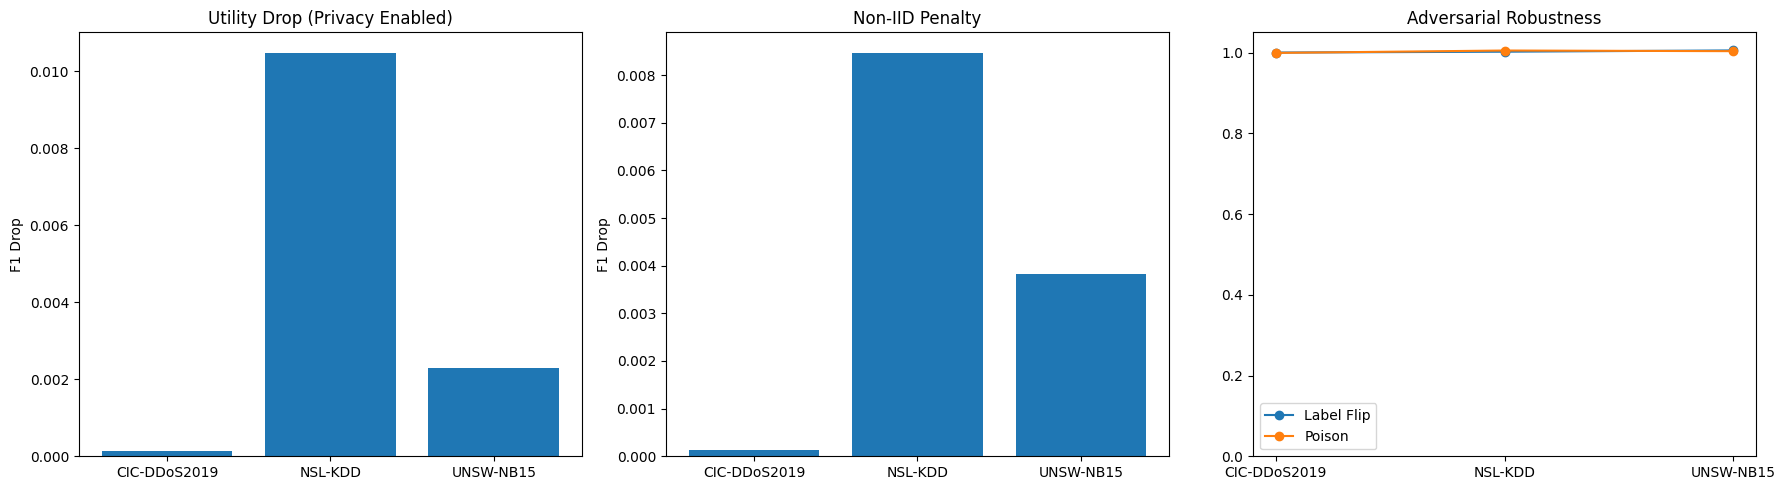

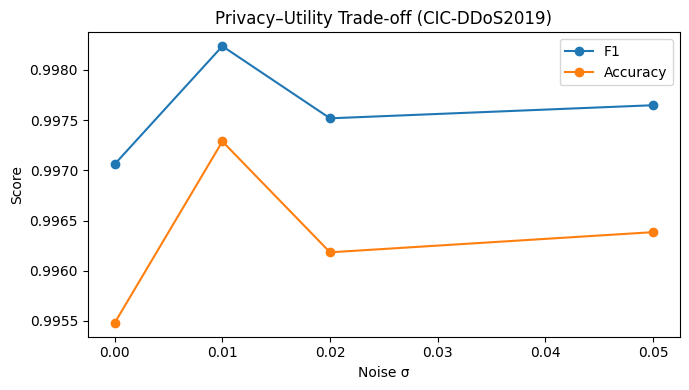

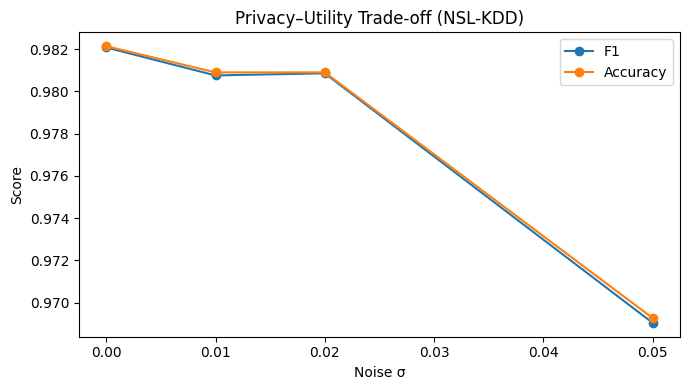

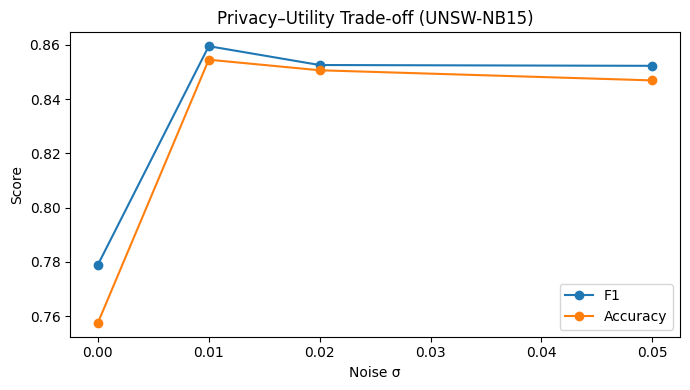

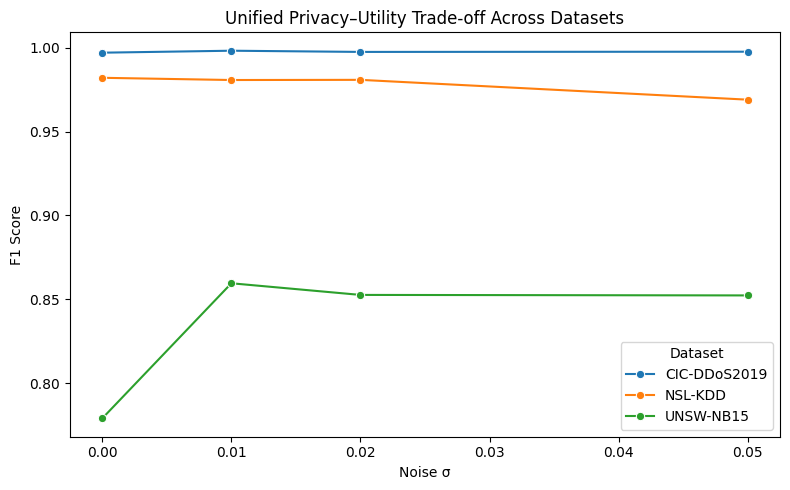

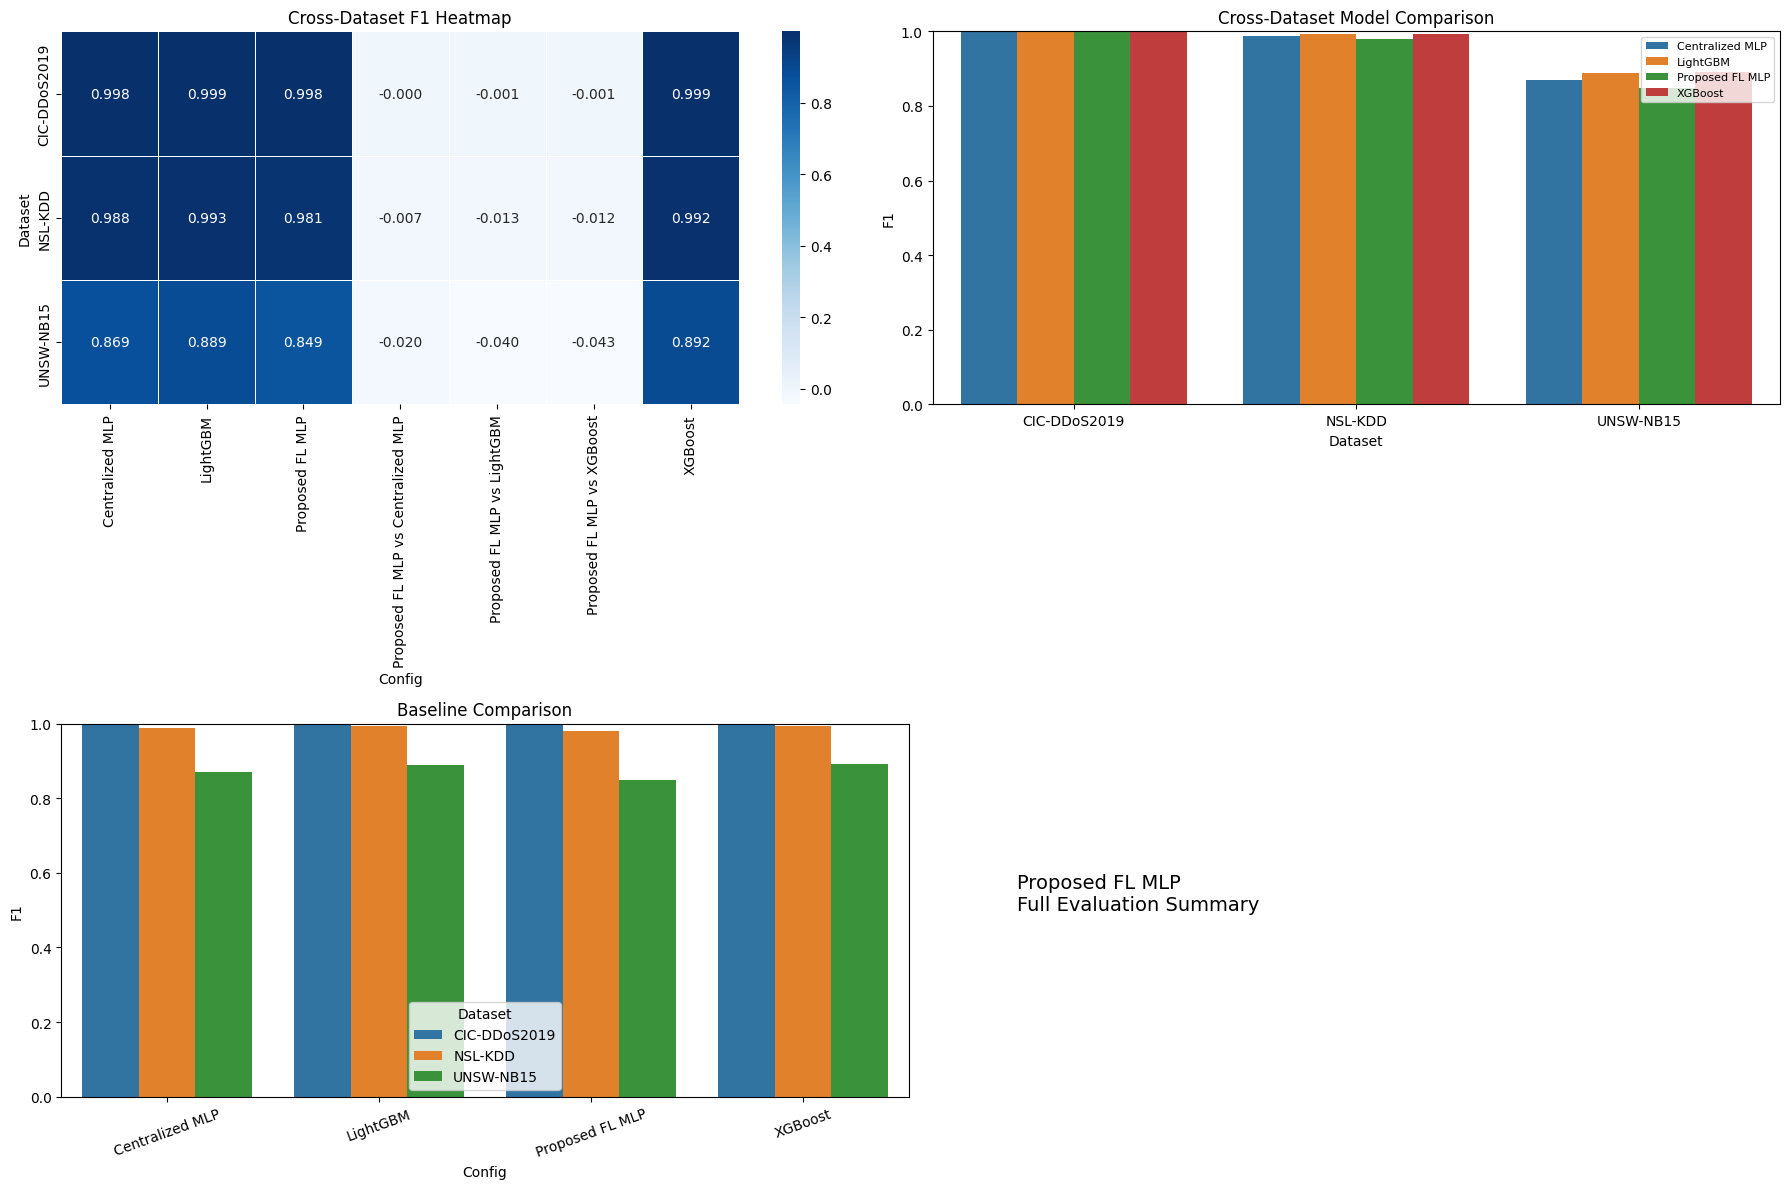

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Privacy Summary
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Utility Drop
axes[0].bar(
    privacy_summary_df["Dataset"],
    privacy_summary_df["Utility_Drop_vs_NoPrivacy"]
)
axes[0].set_title("Utility Drop (Privacy Enabled)")
axes[0].set_ylabel("F1 Drop")

# Non-IID penalty
axes[1].bar(
    privacy_summary_df["Dataset"],
    privacy_summary_df["NonIID_Penalty_vs_IID"]
)
axes[1].set_title("Non-IID Penalty")
axes[1].set_ylabel("F1 Drop")

# Robustness
axes[2].plot(
    privacy_summary_df["Dataset"],
    privacy_summary_df["LabelFlip_Retention"],
    marker="o",
    label="Label Flip"
)
axes[2].plot(
    privacy_summary_df["Dataset"],
    privacy_summary_df["Poison_Retention"],
    marker="o",
    label="Poison"
)
axes[2].set_ylim(0.0, 1.05)
axes[2].set_title("Adversarial Robustness")
axes[2].legend()

plt.tight_layout()
plt.show()


# Privacy–Utility Trade-off (each dataset)

for dataset_name in privacy_tradeoff_df["Dataset"].unique():

    subset = privacy_tradeoff_df[
        privacy_tradeoff_df["Dataset"] == dataset_name
    ]

    plt.figure(figsize=(7, 4))

    plt.plot(subset["sigma"], subset["F1"], marker="o", label="F1")
    plt.plot(subset["sigma"], subset["Accuracy"], marker="o", label="Accuracy")

    plt.xlabel("Noise σ")
    plt.ylabel("Score")
    plt.title(f"Privacy–Utility Trade-off ({dataset_name})")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Unified Privacy–Utility

plt.figure(figsize=(8, 5))

if "Model" in privacy_tradeoff_df.columns:
    sns.lineplot(
        data=privacy_tradeoff_df,
        x="sigma",
        y="F1",
        hue="Dataset",
        style="Model",
        markers=True,
        dashes=False
    )
else:
    sns.lineplot(
        data=privacy_tradeoff_df,
        x="sigma",
        y="F1",
        hue="Dataset",
        marker="o"
    )

plt.xlabel("Noise σ")
plt.ylabel("F1 Score")
plt.title("Unified Privacy–Utility Trade-off Across Datasets")
plt.legend(title="Dataset")

plt.tight_layout()
plt.show()


# Baseline + Heatmap + Cross Dataset

fig = plt.figure(figsize=(18, 12))


# Heatmap (F1)

ax1 = plt.subplot(2, 2, 1)

pivot = results_df.pivot(index="Dataset", columns="Config", values="F1")

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax1
)

ax1.set_title("Cross-Dataset F1 Heatmap")

# Cross-Dataset Bar
ax2 = plt.subplot(2, 2, 2)

sns.barplot(
    data=results_df[~results_df["Config"].str.contains("vs")],
    x="Dataset",
    y="F1",
    hue="Config",
    ax=ax2
)

ax2.set_title("Cross-Dataset Model Comparison")
ax2.set_ylim(0, 1)
ax2.legend(fontsize=8)


# Supporting Baseline per dataset

ax3 = plt.subplot(2, 2, 3)

subset = results_df[~results_df["Config"].str.contains("vs")]

sns.barplot(
    data=subset,
    x="Config",
    y="F1",
    hue="Dataset",
    ax=ax3
)

ax3.set_title("Baseline Comparison")
ax3.set_ylim(0, 1)
ax3.tick_params(axis='x', rotation=20)


ax4 = plt.subplot(2, 2, 4)
ax4.axis("off")
ax4.text(0.1, 0.5, "Proposed FL MLP\nFull Evaluation Summary", fontsize=14)

plt.tight_layout()
plt.show()


## Save all outputs

In [ ]:
OUTPUT_DIR = Path("./privacy_centric_federated_ids_outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

results_df.to_csv(OUTPUT_DIR / "main_results.csv", index=False)
cv_df.to_csv(OUTPUT_DIR / "cv_folds.csv", index=False)
cv_summary_df.to_csv(OUTPUT_DIR / "cv_summary.csv", index=False)
dataset_info_df.to_csv(OUTPUT_DIR / "dataset_info.csv", index=False)
privacy_tradeoff_df.to_csv(OUTPUT_DIR / "privacy_tradeoff.csv", index=False)
ablation_df.to_csv(OUTPUT_DIR / "ablation_study.csv", index=False)
attack_df.to_csv(OUTPUT_DIR / "attack_robustness.csv", index=False)
privacy_summary_df.to_csv(OUTPUT_DIR / "privacy_summary.csv", index=False)
paper_core_df.to_csv(OUTPUT_DIR / "paper_core_summary.csv", index=False)
overhead_df.to_csv(OUTPUT_DIR / "overhead_summary.csv", index=False)
wilcoxon_df.to_csv(OUTPUT_DIR / "wilcoxon_tests.csv", index=False)
friedman_df.to_csv(OUTPUT_DIR / "friedman_test.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", p.name)


Saved outputs to: /content/privacy_centric_federated_ids_outputs
- ablation_study.csv
- attack_robustness.csv
- cv_folds.csv
- cv_summary.csv
- dataset_info.csv
- friedman_test.csv
- main_results.csv
- overhead_summary.csv
- paper_core_summary.csv
- privacy_summary.csv
- privacy_tradeoff.csv
- wilcoxon_tests.csv
